# Learned control of a confined microswimmer through its own far-field flow

**Byjesh N. Radhakrishnan** &nbsp;·&nbsp; byjesh1998@gmail.com

This notebook builds step by step:

1. The hydrodynamic model of a microswimmer in a liquid film, following
   [Cao & Tsang, *Phys. Rev. Fluids* **11**, 044402 (2026)](https://doi.org/10.1103/h2hy-crbv);
2. Checks that every image system satisfies its boundary conditions;
3. A reproduction of the published dynamical modes;
4. A control layer in which the swimmer repositions its own source dipole, solved
   exactly by dynamic programming;
5. The same problem when the swimmer can only sense local flow.

Runtime on a free Colab
CPU instance is roughly 10–15 minutes end to end.

> **Runtime tip.** `FAST = True` (the default) coarsens the *hydrodynamic tables*,
> which is where nearly all the time goes. The numbers then come out somewhat below
> those quoted in the text; set `FAST = False` to reproduce them exactly, at the cost
> of roughly three times the runtime. The policy grid stays fine either way, since
> solving for the policy is cheap.

In [ ]:
# module loading
!pip install -q jax
import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
from functools import partial

jax.config.update("jax_enable_x64", True)

print("jax", jax.__version__, "| devices:", jax.devices())

jax 0.11.1 | devices: [CpuDevice(id=0)]


In [ ]:
# ---------------------------------------------------------------- configuration
FAST = False          # True: coarse grids, a few minutes.  False: finer grids.

NZ_TAB, NTH_TAB = (61, 81) if FAST else (81, 121)   # (z, theta) tabulation
NZ_DP,  NTH_DP  = 81, 97                            # policy grid (cheap: always fine)
CHUNK = 200          # batch size for the Hessian evaluations (memory bound)

---
## 1. The model

A swimmer located in a liquid film with a no-slip wall at $z=0$ and a
free-slip surface at $z=H$. Its far field is represented by two opposite
Stokeslets at

$$\boldsymbol{x}_\pm=\boldsymbol{x}_c\pm\tfrac{\Delta}{2}\hat{\mathbf{e}},
\quad \text{with strength} \quad \boldsymbol{f}_\pm=\pm F\hat{\mathbf{e}},$$

which is force free, plus a source dipole of strength $\sigma$ at

$$\boldsymbol{x}_d=\boldsymbol{x}_c+\Delta_d\,\hat{\mathbf{e}}.$$

The magnitude of force determne the swimming mechanism: $F>0$ gives outward forces (a pusher), $F<0$ inward forces (a puller). The parameter $\Delta_d$ shifts the source dipole toward the front ($>0$) or rear ($<0$) of the body,
and therefore encodes fore–aft geometric asymmetry.

Lengths are scaled by $\Delta$, velocities by the swimming speed, viscosity by
$8\pi\mu$. In these units the Oseen tensor is

$$\hat J_{ij}(\boldsymbol r)=\frac{\delta_{ij}}{r}+\frac{r_ir_j}{r^3}.$$

Then, the source dipole follows from it by

$$\boldsymbol D(\boldsymbol r;\hat{ \mathbf{e}})
=-\tfrac12\nabla^2\big[\hat J(\boldsymbol r)\cdot\hat{\mathbf{e}}\big]
=\frac{3\boldsymbol r(\boldsymbol r\cdot\hat{\boldsymbol e})}{r^5}-\frac{\hat{\mathbf{e}}}{r^3}.$$

We use the *derivative* definition in code, because applying $-\tfrac12\nabla^2$
to the **image** field of a Stokeslet automatically generates the image system of
the source dipole — no separate derivation needed.

In [ ]:
REFL = jnp.array([1.0, 1.0, -1.0])       # Lambda = diag(1,1,-1)

#define Oseen tensor
def stokeslet(r, f):
    "Free-space Stokeslet: (I/r + rr/r^3) . f"
    rn = jnp.sqrt(jnp.dot(r, r))
    return f / rn + r * jnp.dot(r, f) / rn**3

### 1.1 Image system for the no-slip wall

For a Stokeslet at $\boldsymbol X=(X_1,X_2,X_3)$ with $h=X_3>0$, the image is at
$\boldsymbol X^{*}=(X_1,X_2,-X_3)$ and $\boldsymbol R=\boldsymbol x-\boldsymbol X^{*}$ is the arbitary position vector relative to the image.Now, the Blake's image part can be written as

$$u^B_i=-\hat J_{ij}(\boldsymbol R)f_j+2h\,\frac{\partial g_i}{\partial R_l}(\Lambda \boldsymbol f)_l,
\qquad
g_i=\frac{hR_i}{R^3}-\frac{\delta_{i3}}{R}-\frac{R_iR_3}{R^3}.$$

We write the derivative in closed form,

$$\frac{\partial g_i}{\partial R_l}
=h\Big(\frac{\delta_{il}}{R^3}-\frac{3R_iR_l}{R^5}\Big)
+\frac{\delta_{i3}R_l}{R^3}
-\frac{\delta_{il}R_3+R_i\delta_{l3}}{R^3}
+\frac{3R_iR_3R_l}{R^5},$$

rather than differentiating automatically, since it reduce the running time.

In [ ]:
#derivative part in Blakes image
def _blake_dg(R, h):
    "dg_i/dR_l in closed form."
    Rn = jnp.sqrt(jnp.dot(R, R)); I3 = jnp.eye(3)
    e3 = jnp.array([0.0, 0.0, 1.0]); outer = jnp.outer(R, R)
    d  = h * (I3 / Rn**3 - 3.0 * outer / Rn**5)
    d += jnp.outer(e3, R) / Rn**3
    d -= (I3 * R[2] + jnp.outer(R, e3)) / Rn**3
    d += 3.0 * R[2] * outer / Rn**5
    return d

# full Blakes image system
def blake_image(x, X, f):
    "Image part of Blake's solution for a Stokeslet f at X above a wall at z=0."
    h = X[2]
    R = x - jnp.array([X[0], X[1], -X[2]])
    return -stokeslet(R, f) + 2.0 * h * (_blake_dg(R, h) @ (REFL * f))

### 1.2 Image system for the free-slip surface

Let $\sigma_H(\boldsymbol x)=(x_1,x_2,2H-x_3)$. For a Stokeslet the free-slip
image is a mirror Stokeslet with the **normal** force component reversed. More
generally, any Stokes field generated below the surface has free-slip image

$$(\mathcal R\boldsymbol u)(\boldsymbol x)=\Lambda\,\boldsymbol u\big(\sigma_H(\boldsymbol x)\big).$$

When $z=H$ we have $\sigma_H(\boldsymbol x)=\boldsymbol x$, so
$\boldsymbol u+\mathcal R\boldsymbol u=(\mathsf I+\Lambda)\boldsymbol u$ has zero
third component; and the tangential components are even about $z=H$, so their
normal derivative vanishes. Both free-slip conditions, from one reflection.

### 1.3 Four images

Each correction spoils the other boundary, so an infinite series is needed in
principle. Following the paper we keep four:

$$\boldsymbol u^{*}=
\underbrace{\boldsymbol u^{B}(\boldsymbol x;\boldsymbol X,\boldsymbol f)}_{B_1}
+\underbrace{\hat J(\boldsymbol x-\sigma_H(\boldsymbol X))\Lambda\boldsymbol f}_{T_1}
+\underbrace{\Lambda\,\boldsymbol u^{B}(\sigma_H(\boldsymbol x);\boldsymbol X,\boldsymbol f)}_{T_2}
+\underbrace{\boldsymbol u^{B}(\boldsymbol x;\sigma_H(\boldsymbol X),\Lambda\boldsymbol f)}_{B_2}$$,

where $B_1$ fixes $z=0$ for the original, $T_1$ fixes $z=H$ for the original, $T_2$ is
the free-slip image of the whole $B_1$ system, and $B_2$ is the Blake image of the
$T_1$ Stokeslet. So $z=0$ is exact for the pairs (original, $B_1$) and ($T_1$,
$B_2$), and $z=H$ for (original, $T_1$) and ($B_1$, $T_2$). What is left over is
the next, neglected reflection.

In [ ]:
def _mirror_top(x, H):
    return jnp.array([x[0], x[1], 2.0 * H - x[2]])

def stokeslet_images(x, X, f, H):
    "The four image contributions (no free-space term, so smooth at x = X)."
    u_b1 = blake_image(x, X, f)
    u_t1 = stokeslet(x - _mirror_top(X, H), REFL * f)
    u_t2 = REFL * blake_image(_mirror_top(x, H), X, f)
    u_b2 = blake_image(x, _mirror_top(X, H), REFL * f)
    return u_b1 + u_t1 + u_t2 + u_b2

def stokeslet_full(x, X, f, H):
    return stokeslet(x - X, f) + stokeslet_images(x, X, f, H)

def _lap_x(fun):
    "Laplacian in the field point of a vector-valued function."
    def lap(x, *a):
        Hs = jax.hessian(lambda xx: fun(xx, *a))(x)
        return jnp.trace(Hs, axis1=1, axis2=2)
    return lap

def dipole_images(x, X, e, H):
    return -0.5 * _lap_x(stokeslet_images)(x, X, e, H)

def u_star(x, xc, e, F, sigma, dd, H):
    "Reflected (boundary-induced) flow of the whole swimmer at field point x."
    u  = stokeslet_images(x, xc + 0.5 * e,  F * e, H)
    u += stokeslet_images(x, xc - 0.5 * e, -F * e, H)
    u += sigma * dipole_images(x, xc + dd * e, e, H)
    return u

---
## 2. Do the image systems actually work?

Firts, we check the boundary conditions.

In [ ]:
H_t = 5.0; X_t = jnp.array([0.0, 0.0, 2.0]); f_t = jnp.array([0.7, -0.3, 0.5])

u_blake = lambda x: stokeslet(x - X_t, f_t) + blake_image(x, X_t, f_t)

#calculating the stokeslet+ Blake image at two random point on the no-slip wall
print("Blake image pair on the no-slip wall (should be 0):")
for p in [[1., .5, 0.], [3., -2., 0.]]:
    print("   |u| = %.2e" % float(jnp.linalg.norm(u_blake(jnp.array(p)))))


def u_free(x):
    Xs = jnp.array([X_t[0], X_t[1], 2*H_t - X_t[2]])
    return stokeslet(x - X_t, f_t) + stokeslet(x - Xs, REFL * f_t)

#calculating the stokeslet+ reflected image at two random point on the free-slip wall
print("\nFree-slip pair on z = H (need u_z = 0 and du_x/dz = 0):")
for p in [[1., .5, H_t], [3., -2., H_t]]:
    x = jnp.array(p); J = jax.jacfwd(u_free)(x)
    print("   u_z = %+.2e   du_x/dz = %+.2e" % (u_free(x)[2], J[0, 2]))


#calculating the all four contribution at the no-slip wall and near squirmer
print("\nFour-image film: residuals are the size of the first neglected reflection")
u_film = lambda x: stokeslet_full(x, X_t, f_t, H_t)
print("   |u| on z=0      : %.3f" % float(jnp.linalg.norm(u_film(jnp.array([1., .5, 0.])))))
print("   |u| near swimmer: %.3f" % float(jnp.linalg.norm(u_film(jnp.array([1., 0., 2.])))))

Blake image pair on the no-slip wall (should be 0):
   |u| = 5.55e-17
   |u| = 3.93e-17

Free-slip pair on z = H (need u_z = 0 and du_x/dz = 0):
   u_z = +0.00e+00   du_x/dz = +0.00e+00
   u_z = +0.00e+00   du_x/dz = +0.00e+00

Four-image film: residuals are the size of the first neglected reflection
   |u| on z=0      : 0.134
   |u| near swimmer: 1.111


The first two are exact to machine precision. The film residual is about 10% of
the field magnitude near the swimmer — this truncation is the leading systematic
error of the model, and it is inherited from the published formulation rather than
introduced here.

---
## 3. Equations of motion

The swimmer is force and torque free, so its velocities follow from Faxén's laws
applied to the *reflected* field:

$$\boldsymbol v_{HI}=\Big(1+\tfrac{a^2}{6\gamma^2}\nabla^2\Big)\boldsymbol u^{*}(\boldsymbol x_c),
\qquad
\boldsymbol\Omega_{HI}=\tfrac12\nabla\times\boldsymbol u^{*}
+G\,\hat{\mathbf{ e}}\times(\mathsf E^{*}\cdot\hat{\mathbf{e}}),$$

with $\mathsf E^{*}=\tfrac12(\nabla\boldsymbol u^{*}+\nabla\boldsymbol u^{*\mathsf T})$,
$a=\Delta=1$, $\gamma=3$, $G=0.8$, so $a^2/6\gamma^2=1/54$. Then

$$\dot{\boldsymbol x}_c=\hat{\mathbf{e}}+\boldsymbol v_{HI},
\qquad \dot{\hat{\mathbf{e}}}=\boldsymbol\Omega_{HI}\times\hat{\mathbf{e}}.$$

In [ ]:
FAX_C, G_SHAPE = 1.0/54.0, 0.8

#this function returns the translational and angular velocities of squirmer
def hydro_terms(xc, e, F, sigma, dd, H):
    fun = lambda x: u_star(x, xc, e, F, sigma, dd, H)
    u   = fun(xc)
    Jm  = jax.jacfwd(fun)(xc)                       # Jm[i,j] = du_i/dx_j
    Hs  = jax.hessian(fun)(xc)
    lap = jnp.trace(Hs, axis1=1, axis2=2)
    v_hi = u + FAX_C * lap
    vort = jnp.array([Jm[2,1]-Jm[1,2], Jm[0,2]-Jm[2,0], Jm[1,0]-Jm[0,1]])
    E    = 0.5 * (Jm + Jm.T)
    omega = 0.5 * vort + G_SHAPE * jnp.cross(e, E @ e)
    return v_hi, omega

### 3.1 The dynamics closes on $(z,\theta)$ — and a sign trap

The film looks the same everywhere sideways, so $\boldsymbol u^{*}$ at the body
centre depends only on the height $z$ and the tilt $\theta$. Writing
$\hat{\mathbf{e}}=(\cos\theta,0,\sin\theta)$ and
$\boldsymbol\Omega_{HI}=\Omega_y\boldsymbol e_y$,

$$\boldsymbol\Omega\times\hat{\\mathbf{e}}=(\Omega_y\sin\theta,\,0,\,-\Omega_y\cos\theta),
\qquad
\dot{\hat{\mathbf{e}}}=\dot\theta(-\sin\theta,0,\cos\theta),$$

and matching components gives

$$\dot\theta=-\Omega_y$$

So the whole system is two-dimensional:

$$\dot z=\sin\theta+w(z,\theta),\qquad
\dot\theta=-\Omega_y(z,\theta),\qquad
\dot x=\cos\theta+u(z,\theta).$$

We can tabulate $(u,w,\Omega_y)$ once on a grid and make
trajectories essentially free.

In [ ]:
@jax.jit
def _terms(z, th, F, sigma, dd, H):
    xc = jnp.array([0.0, 0.0, z])
    e  = jnp.array([jnp.cos(th), 0.0, jnp.sin(th)])
    v, om = hydro_terms(xc, e, F, sigma, dd, H)
    return jnp.array([v[0], v[2], om[1]])          # u, w, Omega_y

_terms_batch = jax.jit(jax.vmap(_terms, in_axes=(0, 0, None, None, None, None)))

_CACHE = {}
def build_table(F, sigma, dd, H, nz=None, nth=None, margin=0.55):
    nz  = nz  or NZ_TAB
    nth = nth or NTH_TAB
    key = (F, sigma, dd, H, nz, nth, margin)
    if key in _CACHE: return _CACHE[key]
    zs  = np.linspace(margin, H - margin, nz)
    ths = np.linspace(-np.pi, np.pi, nth)
    ZZ, TT = np.meshgrid(zs, ths, indexing="ij")
    zf, tf = ZZ.ravel(), TT.ravel()
    out = np.empty((zf.size, 3))
    for i in range(0, zf.size, CHUNK):          # chunked: the Hessians are memory-hungry
        out[i:i+CHUNK] = np.asarray(_terms_batch(
            jnp.array(zf[i:i+CHUNK]), jnp.array(tf[i:i+CHUNK]), F, sigma, dd, H))
    _CACHE[key] = (zs, ths, out.reshape(nz, nth, 3))
    return _CACHE[key]

class Field:
    "Bilinear interpolation of a tabulated (u, w, Omega_y)."
    def __init__(self, zs, ths, tab):
        self.zs, self.ths, self.tab = zs, ths, tab
        self.dz, self.dth = zs[1]-zs[0], ths[1]-ths[0]
    def __call__(self, z, th):
        th = (th + np.pi) % (2*np.pi) - np.pi
        fz = np.clip((z - self.zs[0]) / self.dz, 0, len(self.zs) - 1.0001)
        ft = np.clip((th - self.ths[0]) / self.dth, 0, len(self.ths) - 1.0001)
        i, j = int(fz), int(ft); a, b = fz - i, ft - j; t = self.tab
        return ((1-a)*(1-b)*t[i,j] + a*(1-b)*t[i+1,j]
                + (1-a)*b*t[i,j+1] + a*b*t[i+1,j+1])
    def inside(self, z):
        return self.zs[0] <= z <= self.zs[-1]

def get_field(F, sigma, dd, H, **kw):
    return Field(*build_table(F, sigma, dd, H, **kw))

def trajectory(field, z0, th0, T=100.0, dt=0.01, x0=0.0):
    "RK4 in (x, z, theta); stops at a boundary."
    n = int(T/dt); X = np.empty((n+1, 3)); s = np.array([x0, z0, th0]); X[0] = s
    hit = False
    def f(s):
        u, w, om = field(s[1], s[2])
        return np.array([np.cos(s[2]) + u, np.sin(s[2]) + w, -om])   # note the minus
    for k in range(n):
        if not field.inside(s[1]):
            hit = True; X = X[:k+1]; break
        k1 = f(s); k2 = f(s + .5*dt*k1); k3 = f(s + .5*dt*k2); k4 = f(s + dt*k3)
        s = s + (dt/6.)*(k1 + 2*k2 + 2*k3 + k4)
        s[2] = (s[2] + np.pi) % (2*np.pi) - np.pi
        X[k+1] = s
    return X, hit

print("ready to preoceed")

ready to preoceed


---
## 4. Reproducing the published modes

The test of an implementation is whether it recovers results it was not fitted to.
The paper's Fig. 3(a) is readable to about two significant figures: the pure pusher
reaches the bottom wall at $x\approx50$ and $280$ from $z_0=3$ and $5$, and the
free surface at $x\approx90$ from $z_0=7$.

In [ ]:
f = get_field(0.5, 0.0, 0.0, 10.0)
print("Pure pusher (F=0.5, sigma=0, H=10)   [paper: x ~ 50, 280, 90]")
for z0 in (3., 5., 7.):
    X, hit = trajectory(f, z0, 0.0, T=800, dt=0.02)
    print("   z0=%.0f -> %s at x=%.0f" %
          (z0, "bottom wall" if X[-1,1] < 5 else "free surface", X[-1,0]))

f = get_field(-0.5, 0.0, 0.0, 10.0)
print("\nPure puller (F=-0.5): expect centreline sliding")
for z0 in (3., 5., 7.):
    X, hit = trajectory(f, z0, 0.0, T=1000, dt=0.02)
    print("   z0=%.0f -> z_end=%.3f" % (z0, X[-1,1]))

Pure pusher (F=0.5, sigma=0, H=10)   [paper: x ~ 50, 280, 90]
   z0=3 -> bottom wall at x=51
   z0=5 -> bottom wall at x=291
   z0=7 -> free surface at x=91

Pure puller (F=-0.5): expect centreline sliding
   z0=3 -> z_end=5.704
   z0=5 -> z_end=5.713
   z0=7 -> z_end=5.721


The puller settles slightly **above** the midplane $H/2=5$: the no-slip wall
reflects more strongly than the free surface, so the film is asymmetric.

Now the central result of the paper. With both a Stokeslet pair and a source
dipole, pushers develop a growing oscillation and pullers a decaying one — and
the mode is selected by where the dipole sits on the body.

Dipole position sweep (pusher, F=0.03, sigma=0.05, H=2):
   dd=-0.4 -> damped                   (contact=False)
   dd=+0.0 -> amplified                (contact=True)
   dd=+0.4 -> no sustained oscillation (contact=True)


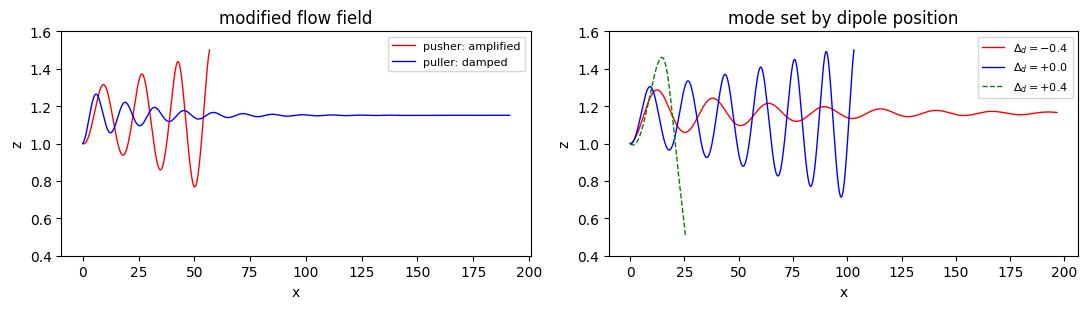

In [ ]:
def trend(z, z0):
    d = np.diff(z); idx = np.where(np.sign(d[1:]) * np.sign(d[:-1]) < 0)[0] + 1
    a = np.abs(z[idx] - z0)
    if len(a) < 3: return "no sustained oscillation"
    return "amplified" if a[-1] > 1.15*a[0] else ("damped" if a[-1] < .85*a[0] else "steady")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for F, sig, lab, c in [(0.05, 0.05, "pusher: amplified", "red"),
                       (-0.10, 0.10, "puller: damped",   "blue")]:
    X, _ = trajectory(get_field(F, sig, 0.0, 2.0, margin=0.5), 1.0, 0.0, T=200, dt=0.01)
    ax[0].plot(X[:,0], X[:,1], c=c, lw=1, label=lab)
ax[0].set_title("modified flow field"); ax[0].legend(fontsize=8); ax[0].set_ylim(.4, 1.6)

print("Dipole position sweep (pusher, F=0.03, sigma=0.05, H=2):")
for dd, c, ls in zip([-0.4, 0.0, 0.4], ["red", "blue", "green"], ["-","-","--"]):
    X, hit = trajectory(get_field(0.03, 0.05, dd, 2.0, margin=0.5), 1.0, 0.0, T=200, dt=0.01)
    print("   dd=%+.1f -> %-24s (contact=%s)" % (dd, trend(X[:,1], 1.0), hit))
    ax[1].plot(X[:,0], X[:,1], c=c, ls=ls, lw=1, label=r"$\Delta_d=%+.1f$" % dd)
ax[1].set_title("mode set by dipole position"); ax[1].legend(fontsize=8); ax[1].set_ylim(.4, 1.6)
for a in ax: a.set_xlabel("x"); a.set_ylabel("z")
plt.tight_layout(); plt.show()

Rear-shifted dipole → damped. Central → amplified. Front-shifted → straight into
the boundary. Same swimmer, same fluid; the outcome is set by body geometry.

That is the observation the rest of the notebook builds on: if shape selects the
mode, then shape is a control variable.

---
## 5. The control problem

Take a pusher whose passive behaviour is amplified oscillation ending in a crash
($F=0.05$, $\sigma=0.05$, $H=2$). Let it reset its dipole position every $\tau=2$
time units to one of

$$\Delta_d\in\{-0.4,\,-0.2,\,0,\,+0.2,\,+0.4\}.$$

**Task:** hold a target height $z^{*}=1.35$ near the free surface — deliberately
inside the region where the instability throws it into the wall. Reward per
interval:

$$r(s,a)=\int_0^\tau\Big(1-\frac{|z(t)-z^{*}|}{\ell}\Big)dt-C\,\mathbb 1[\text{contact}],
\qquad \ell=0.5,\;C=20,$$

over a horizon $T=300$, i.e. 150 decisions, so the best possible score is about 300. The linear penalty
$1-|z-z^{*}|/\ell$
could equally have been quadratic, or Gaussian, or a hard indicator for being inside a band. The tolerance
$\ell=0.5$ is essentially the film half-width, chosen so the reward is roughly zero at the boundaries. The penalty $C=20$ is worth about 20 time units of perfect tracking — enough to make death expensive without dominating everything.

In [ ]:
from jax.scipy.ndimage import map_coordinates
ACTIONS = (-0.4, -0.2, 0.0, 0.2, 0.4)
F_C, SIG_C, H_C, Z_STAR, TOL, PEN = 0.05, 0.05, 2.0, 1.35, 0.5, 20.0
DT, HOLD, T_HOR = 0.02, 2.0, 300.0

print("building %d tables (~30 s each the first time)" % len(ACTIONS))
_flds = [get_field(F_C, SIG_C, dd, H_C, margin=0.5) for dd in ACTIONS]
TAB   = jnp.array(np.stack([f.tab for f in _flds]))
ZLO, ZHI = float(_flds[0].zs[0]), float(_flds[0].zs[-1])
NZg, NTHg = TAB.shape[1], TAB.shape[2]
N_HOLD, N_DEC = int(HOLD/DT), int(T_HOR/HOLD)

def _interp(a, z, th):
    fz = (z - ZLO)/(ZHI - ZLO)*(NZg - 1)
    ft = (th + jnp.pi)/(2*jnp.pi)*(NTHg - 1)
    c  = jnp.array([[fz], [ft]])
    return jnp.stack([map_coordinates(TAB[a][:,:,k], c, order=1, mode="nearest")[0]
                      for k in range(3)])

@jax.jit
def step_hold(state, a):
    "Integrate one decision interval. state = (x, z, theta, dead)."
    def rhs(s):
        u, w, om = _interp(a, s[1], s[2])
        return jnp.array([jnp.cos(s[2]) + u, jnp.sin(s[2]) + w, -om])
    def body(c, _):
        s, dead, acc = c
        alive = 1.0 - dead
        k1 = rhs(s); k2 = rhs(s + .5*DT*k1); k3 = rhs(s + .5*DT*k2); k4 = rhs(s + DT*k3)
        sn = s + (DT/6.)*(k1 + 2*k2 + 2*k3 + k4)
        sn = sn.at[2].set((sn[2] + jnp.pi) % (2*jnp.pi) - jnp.pi)
        sn = jnp.where(dead > .5, s, sn)
        hit = (sn[1] <= ZLO) | (sn[1] >= ZHI)
        dead_n = jnp.maximum(dead, hit.astype(jnp.float64))
        acc = acc + alive * DT * (1.0 - jnp.abs(sn[1] - Z_STAR)/TOL)
        return (sn, dead_n, acc), None
    (s, dead, acc), _ = jax.lax.scan(body, (state[:3], state[3], 0.0), None, length=N_HOLD)
    acc = acc - PEN * (dead - state[3])
    return jnp.concatenate([s, jnp.array([dead])]), acc

def run_policy(pick, z0, th0, sense=False):
    "pick(z, th) or, if sense=True, pick(obs) with obs from the previous action."
    s = jnp.array([0., z0, th0, 0.]); a = 2; tot = 0.; zs = []
    for _ in range(N_DEC):
        a = pick(np.asarray(_interp(a, s[1], s[2]))) if sense else pick(float(s[1]), float(s[2]))
        s, r = step_hold(s, a); tot += float(r); zs.append(float(s[1]))
        if float(s[3]) > .5: break
    return tot, np.array(zs)

rng = np.random.default_rng(0)
STARTS = [(1.0 + rng.uniform(-.15,.15), rng.uniform(-.15,.15)) for _ in range(20)]
print("\nFixed morphologies (never change shape):")
for ai, dd in enumerate(ACTIONS):
    sc = np.mean([run_policy(lambda z,t,ai=ai: ai, z0, t0)[0] for z0,t0 in STARTS])
    print("   dd=%+.1f  mean return %8.2f" % (dd, sc))

building 5 tables (~30 s each the first time)

Fixed morphologies (never change shape):
   dd=-0.4  mean return   133.22
   dd=-0.2  mean return   146.53
   dd=+0.0  mean return    -2.15
   dd=+0.2  mean return   -11.15
   dd=+0.4  mean return   -16.19


The nominal pusher ($\Delta_d=0$) dies almost at once. The best *fixed* shape does
respectably. The question is whether **changing** shape does better.

---
## 6. Solving it exactly, instead of learning it

The obvious approach is reinforcement learning, and it is worth being precise about why I do not use it. The first Q-learning run results turned
out to depend heavily on configuration and seed, and did not survive. I am not sure whether RL fails, but it can also be implemented as follows.


The state is only two numbers, and the dynamics is deterministic and
simulable. So the optimum can be computed rather than learned, by value
iteration:

$$V(s)=\max_a\Big[r(s,a)+\gamma\,(1-d)\,V\big(\Phi^\tau_a(s)\big)\Big],\qquad\gamma=0.995.$$

Here, the first term is earned rate right now, and the second term is worth of where squirmer is landing. The parameter $\gamma$ values assert distant rewards are less certain than immediate ones.

One can do it is like solving a maze from the exit. Start with $V=0$ everywhere.
One sweep gives the best action if you had one decision left. The next sweep uses
those values to solve the two-decision problem, and so on until the numbers stop
moving. Trial and error is only necessary when you cannot simulate the world.

In [ ]:
GAMMA_D = 0.995
zs_d  = np.linspace(ZLO + 1e-6, ZHI - 1e-6, NZ_DP)
ths_d = np.linspace(-np.pi, np.pi, NTH_DP)
ZZ, TT = np.meshgrid(zs_d, ths_d, indexing="ij")
S = jnp.array(np.stack([np.zeros(ZZ.size), ZZ.ravel(), TT.ravel(), np.zeros(ZZ.size)], 1))

NS, R, D = [], [], []
for a in range(len(ACTIONS)):
    sn, r = jax.jit(jax.vmap(lambda s: step_hold(s, a)))(S)
    NS.append(np.asarray(sn[:,1:3])); R.append(np.asarray(r)); D.append(np.asarray(sn[:,3]))
NS, R, D = np.stack(NS), np.stack(R), np.stack(D)
print("transition model:", NS.shape)

dz, dth = zs_d[1]-zs_d[0], ths_d[1]-ths_d[0]
fz = np.clip((NS[:,:,0]-zs_d[0])/dz, 0, NZ_DP-1.0001)
ft = np.clip((NS[:,:,1]-ths_d[0])/dth, 0, NTH_DP-1.0001)
i0, j0 = fz.astype(int), ft.astype(int); aa, bb = fz-i0, ft-j0
IDX = [(i0*NTH_DP+j0, (1-aa)*(1-bb)), ((i0+1)*NTH_DP+j0, aa*(1-bb)),
       (i0*NTH_DP+j0+1, (1-aa)*bb),   ((i0+1)*NTH_DP+j0+1, aa*bb)]
alive = 1.0 - D

V = np.zeros(NZ_DP*NTH_DP)
for it in range(2000):
    Q = np.empty((len(ACTIONS), NZ_DP*NTH_DP))
    for a in range(len(ACTIONS)):
        Q[a] = R[a] + GAMMA_D*alive[a]*sum(w[a]*V[i[a]] for i, w in IDX)
    Vn = Q.max(0)
    if np.max(np.abs(Vn - V)) < 1e-9: V = Vn; break
    V = Vn
pol = Q.argmax(0).reshape(NZ_DP, NTH_DP); V = V.reshape(NZ_DP, NTH_DP)
print("converged after %d sweeps" % it)

def pi_star(z, th):
    i = int(np.clip(np.searchsorted(zs_d, z)-1, 0, NZ_DP-1))
    j = int(np.clip(np.searchsorted(ths_d, th)-1, 0, NTH_DP-1))
    return int(pol[i, j])

dp_scores = [run_policy(pi_star, z0, t0)[0] for z0, t0 in STARTS]
print("\noptimal state feedback: mean return %.1f" % np.mean(dp_scores))
print("action usage:", np.round(np.bincount(pol.ravel(), minlength=5)/pol.size, 2))

transition model: (5, 7857, 2)
converged after 1999 sweeps

optimal state feedback: mean return 187.1
action usage: [0.37 0.11 0.12 0.06 0.35]


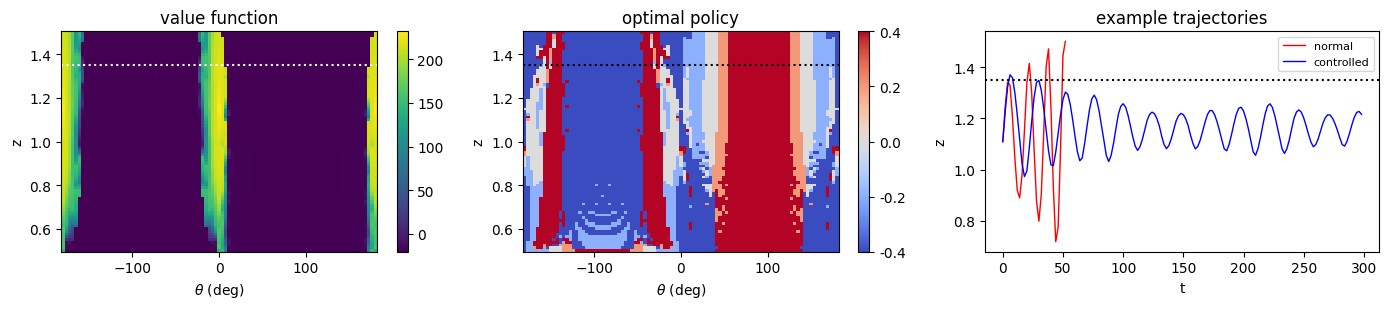

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
im = ax[0].pcolormesh(np.degrees(ths_d), zs_d, V, cmap="viridis", shading="auto")
plt.colorbar(im, ax=ax[0]); ax[0].set_title("value function"); ax[0].axhline(Z_STAR, c="w", ls=":")
im = ax[1].pcolormesh(np.degrees(ths_d), zs_d, pol, cmap="coolwarm", shading="auto", vmin=0, vmax=4)
cb = plt.colorbar(im, ax=ax[1], ticks=range(5)); cb.ax.set_yticklabels([str(a) for a in ACTIONS])
ax[1].set_title("optimal policy"); ax[1].axhline(Z_STAR, c="k", ls=":")
for a in ax[:2]: a.set_xlabel(r"$\theta$ (deg)"); a.set_ylabel("z")
_, zp = run_policy(lambda z,t: 2, 1.0, 0.05)
_, zc = run_policy(pi_star, 1.0, 0.05)
ax[2].plot(np.arange(len(zp))*HOLD, zp, c="red", lw=1, label="normal")
ax[2].plot(np.arange(len(zc))*HOLD, zc, c="blue", lw=1, label="controlled")
ax[2].axhline(Z_STAR, c="k", ls=":"); ax[2].set_xlabel("t"); ax[2].set_ylabel("z")
ax[2].legend(fontsize=8); ax[2].set_title("example trajectories")
plt.tight_layout(); plt.show()

Two things to notice.

**The policy is using switching between extrema.** It spends most of the state space at the two *extreme*
dipole positions, hardly using the intermediate ones. Rather than finding a shape
with nice passive dynamics and keeping it, the controller alternates between the
amplified and damped modes.

**It trades tracking for survival.** The controlled swimmer settles into a bounded
limit cycle somewhat below $z^{*}$ rather than sitting exactly on target. Hovering
precisely at $z^{*}$ is not worth the risk of contact.

---
## 7. Taking away the swimmer's knowledge

The above methode assumes the swimmer knows its own height and tilt. No real bacterium
does. What it can feel is the fluid acting on it — how fast it is being spun and
whether it is drifting up or down. So restrict the observation to

$$o=\big(\Omega_y,\;w\big),$$

binned $12\times12$ at the quantiles of the tabulated values (quantiles, not even
spacing, so no bin is wasted on the tails). Note that what the swimmer feels
depends on the shape it currently holds, so it senses under its previous action —
you feel the consequences of your current body, then change it.

A policy is now just a lookup table with 144 entries. We build it two ways.

### copy the expert through the sensor

In [ ]:
NB = 12
tab_all = np.asarray(TAB)
E_OM = np.quantile(tab_all[:,:,:,2], np.linspace(0,1,NB+1))[1:-1]
E_W  = np.quantile(tab_all[:,:,:,1], np.linspace(0,1,NB+1))[1:-1]

def obs_bin(sensed):
    u, w, om = sensed
    return int(np.searchsorted(E_OM, om))*NB + int(np.searchsorted(E_W, w))

# ---- method 1: copy the expert through the sensor (behaviour cloning)
pairs = []
for z0, t0 in [(1.0+rng.uniform(-.15,.15), rng.uniform(-.15,.15)) for _ in range(150)]:
    s = jnp.array([0., z0, t0, 0.]); a = 2
    for _ in range(N_DEC):
        a_star = pi_star(float(s[1]), float(s[2]))
        pairs.append((obs_bin(np.asarray(_interp(a, s[1], s[2]))), a_star))
        s, _r = step_hold(s, a_star); a = a_star
        if float(s[3]) > .5: break

cnt = np.zeros((NB*NB, len(ACTIONS)))
for o, a in pairs: cnt[o, a] += 1
m_clone = np.where(cnt.sum(1) > 0, cnt.argmax(1), 2)
print("majority action matches the expert %.0f%% of the time" % (100*cnt.max(1).sum()/cnt.sum()))

clone_scores = [run_policy(lambda o: int(m_clone[obs_bin(o)]), z0, t0, sense=True)[0]
                for z0, t0 in STARTS]
print("cloned policy: mean return %.1f" % np.mean(clone_scores))

majority action matches the expert 67% of the time
cloned policy: mean return 94.6


Cloning **fails** — typically worse than never changing shape at all, despite
reproducing roughly two thirds of the expert's decisions.

The reason is aliasing. Two genuinely different situations can feel identical: a
swimmer drifting up near the ceiling and one drifting up near the floor may
register the same spin and drift, and they need opposite responses. The expert
distinguishes them because it sees $z$; the copy inherits contradictory advice and
resolves it by majority vote, which is fatally wrong for the minority case.

So instead of imitating, **optimise for the sensor directly**: keep the same
144-entry table, and change entries only when doing so actually improves the score.

In [ ]:
def eval_map(m, n=14, seed=3):
    r2 = np.random.default_rng(seed); tot, visit = [], np.zeros(NB*NB)
    for _ in range(n):
        z0 = 1.0 + r2.uniform(-.15,.15); t0 = r2.uniform(-.15,.15)
        s = jnp.array([0., z0, t0, 0.]); a = 2; T = 0.
        for _ in range(N_DEC):
            o = obs_bin(np.asarray(_interp(a, s[1], s[2]))); visit[o] += 1
            a = int(m[o]); s, r = step_hold(s, a); T += float(r)
            if float(s[3]) > .5: break
        tot.append(T)
    return np.mean(tot), visit

m_opt = m_clone.copy()
best, visit = eval_map(m_opt)
print("starting from the clone: %.1f" % best)
order = np.argsort(-visit)[:30]              # only bins the swimmer actually visits
for sweep in range(2):                       # ~2 min per sweep
    for o in order:
        cur = m_opt[o]
        for a in range(len(ACTIONS)):
            if a == cur: continue
            m_opt[o] = a; v, _ = eval_map(m_opt)
            if v > best + 1e-9: best, cur = v, a
            else: m_opt[o] = cur
    print("  after sweep %d: %.1f" % (sweep + 1, best))

opt_scores = [run_policy(lambda o: int(m_opt[obs_bin(o)]), z0, t0, sense=True)[0]
              for z0, t0 in STARTS]
print("\nheld-out evaluation: %.1f" % np.mean(opt_scores))
print("(the gap from the training score above is mild overfitting to 14 episodes)")

starting from the clone: 128.3
  after sweep 1: 173.1
  after sweep 2: 173.1

held-out evaluation: 166.7
(the gap from the training score above is mild overfitting to 14 episodes)


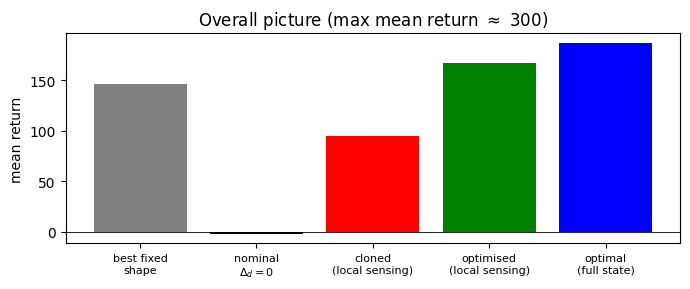

best fixed shape                     146.5
nominal $\Delta_d=0$                  -2.2
cloned (local sensing)                94.6
optimised (local sensing)            166.7
optimal (full state)                 187.1

local sensing recovers 89% of the full-state optimum


In [ ]:
best_fixed = max(np.mean([run_policy(lambda z,t,ai=ai: ai, z0, t0)[0] for z0,t0 in STARTS])
                 for ai in range(len(ACTIONS)))
labels = ["best fixed\nshape", "nominal\n$\\Delta_d=0$", "cloned\n(local sensing)",
          "optimised\n(local sensing)", "optimal\n(full state)"]
vals = [best_fixed,
        np.mean([run_policy(lambda z,t: 2, z0, t0)[0] for z0,t0 in STARTS]),
        np.mean(clone_scores), np.mean(opt_scores), np.mean(dp_scores)]
plt.figure(figsize=(7,3))
plt.bar(range(5), vals, color=["grey","black","red","green","blue"])
plt.xticks(range(5), labels, fontsize=8); plt.axhline(0, c="k", lw=.6)
plt.ylabel("mean return"); plt.title("Overall picture (max mean return $\\approx$ 300)")
plt.tight_layout(); plt.show()
for l, v in zip(labels, vals): print("%-34s %7.1f" % (l.replace("\n"," "), v))
print("\nlocal sensing recovers %.0f%% of the full-state optimum" % (100*vals[3]/vals[4]))

---
## 8. What this shows

**Morphology is an effective actuator.** With paper-resolution grids, optimal
switching beats the best fixed dipole position by 28% (187.1 against 146.5) and
converts a swimmer that fails within a tenth of the horizon into one that survives
it entirely.

**The optimal strategy is switching between extrema**, playing the amplified mode against the
damped mode rather than settling on a stable intermediate shape.

**Local sensing suffices — but only with sensor-aware optimisation.** A swimmer
feeling only its own rotation and drift recovers 89% of the full-state optimum
when its policy is optimised for that sensor, yet collapses below the passive
baseline when it copies the optimal state-feedback policy through the same sensor.
Optimal estimation followed by optimal control is not the same as optimal control
under the sensor, which is the object that matters for a real organism.

### Limitations

- Four-image truncation leaves ~10% boundary residuals.
- Coarse action set, fixed decision interval, one parameter point, one task.
- The dynamics is deterministic: no rotational diffusion, no sensor noise.
- Coordinate ascent is local search over the most-visited bins, so 89% is a lower
  bound rather than a certified optimum.
- With `FAST = True` the numbers here will differ somewhat from those quoted above.

### Natural next steps

Recurrent policies, to test whether memory closes the remaining gap under partial
observability; several interacting swimmers, where each acts on its neighbours'
flow signatures and where the published work identifies collective dynamics as the
open direction; and the dissipative cost of the learned strategies, which becomes
a non-trivial question once the policy or the sensing is stochastic.